In [77]:
import sys
import math
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from experiment_test import (
    TASKS,
    ROUNDS,
    LOCAL_EPOCHS,
    OUT_ROOT,
    TRAIN_SELECTED_GRAPHS_CSV_PATH,
    TRAIN_SELECTED_EXPERIMENT_LOG_PATH,
)

print('rounds:', ROUNDS)
print('local rounds:', LOCAL_EPOCHS)
print('log dir:', OUT_ROOT)
print('tasks:', TASKS)

rounds: 10
local rounds: 1
log dir: andrea/experiment_test_runs
tasks: ['cycle2', 'cycle3', 'cycle4', 'cycle5']


In [ ]:
def normalize_mcw(x):
    if pd.isna(x):
        return "None"
    return str(x)


def stderr(x):
    x = pd.Series(x).dropna()
    if len(x) <= 1:
        return 0.0
    return x.std(ddof=1) / np.sqrt(len(x))


def resolve_existing_path(path_like):
    p = Path(path_like)
    candidates = [
        p,
        Path.cwd() / p,
        ROOT / p,
        Path("/mnt/data") / p.name,
        Path("/mnt/data") / str(p).replace("andrea/", ""),
        ROOT / str(p).replace("andrea/", ""),
    ]
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    raise FileNotFoundError(f"Could not resolve path: {path_like}")


def resolve_run_dir(out_dir):
    p = Path(str(out_dir))
    candidates = [
        p,
        Path.cwd() / p,
        ROOT / p,
        ROOT / str(p).replace("andrea/", ""),
        Path("/mnt/data") / p,
        Path("/mnt/data") / str(p).replace("andrea/", ""),
    ]
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    return None


def cfg_label(mcw_norm, num_layers):
    return f"mcw={mcw_norm} | layers={int(num_layers)}"


def aggregate_curve(curves, x_col, y_col):
    if not curves:
        return pd.DataFrame(columns=[x_col, "mean", "std", "n"])
    df = pd.concat(curves, ignore_index=True)
    out = (
        df.groupby(x_col, as_index=False)[y_col]
        .agg(mean="mean", std="std", n="count")
        .sort_values(x_col)
    )
    out["std"] = out["std"].fillna(0.0)
    return out


def load_local_run(run_dir):
    local_csv = run_dir / "local.csv"
    if not local_csv.exists():
        raise FileNotFoundError(f"Missing local.csv in {run_dir}")
    df = pd.read_csv(local_csv)
    return df


def show_selected_overview(selected, tasks):
    if isinstance(selected, pd.DataFrame):
        row = selected.iloc[0]
    else:
        row = selected

    meta_cols = ["graph_id", "dataset_id", "type", "selected_profile"]
    for col in meta_cols:
        print(f"{col}: ", row[col])

    records = []
    for task in tasks:

        rec = {
            "task": task,
            "pos_rate_mean": row.get(f"{task}_pos_rate_mean", pd.NA),
            "pos_rate_max_diff_from_mean": row.get(
                f"{task}_pos_rate_max_diff_from_mean", pd.NA
            ),
            "pos_nodes_mean": row.get(f"{task}_pos_nodes_mean", pd.NA),
            "pos_nodes_max_diff_from_mean": row.get(
                f"{task}_pos_nodes_max_diff_from_mean", pd.NA
            ),
        }
        records.append(rec)

    overview = pd.DataFrame(records)

    for c in [
        "pos_rate_mean",
        "pos_rate_max_diff_from_mean",
        "pos_nodes_mean",
        "pos_nodes_max_diff_from_mean",
    ]:
        if c in overview.columns:
            overview[c] = pd.to_numeric(overview[c], errors="coerce").round(3)

    display(overview)
    print("\n")
    return overview

In [54]:
all_exp = pd.read_csv(experiment_path)
all_exp["mcw"] = all_exp["mcw"].apply(normalize_mcw)

In [58]:
configs = (
    all_exp[["mcw", "num_layers"]]
    .drop_duplicates()
    .apply(tuple, axis=1)
    .tolist()
)

n_cfg = len(configs)

print(f"{n_cfg} configs:", configs)

4 configs: [('auto', 3), ('auto', 6), ('None', 3), ('None', 6)]


In [76]:
cols = ["graph_id", "out_dir", "mcw", "num_layers"]
print(all_exp[cols])

    graph_id                                            out_dir   mcw  \
0        751  andrea/experiment_test_runs/data_2500_6_5.5_ch...  auto   
1        108  andrea/experiment_test_runs/data_2000_6_2.5_ch...  auto   
2        623  andrea/experiment_test_runs/data_1500_5_1.5_ch...  auto   
3        751  andrea/experiment_test_runs/data_2500_6_5.5_ch...  auto   
4        108  andrea/experiment_test_runs/data_2000_6_2.5_ch...  auto   
5        623  andrea/experiment_test_runs/data_1500_5_1.5_ch...  auto   
6        751  andrea/experiment_test_runs/data_2500_6_5.5_ch...  None   
7        108  andrea/experiment_test_runs/data_2000_6_2.5_ch...  None   
8        623  andrea/experiment_test_runs/data_1500_5_1.5_ch...  None   
9        751  andrea/experiment_test_runs/data_2500_6_5.5_ch...  None   
10       108  andrea/experiment_test_runs/data_2000_6_2.5_ch...  None   
11       623  andrea/experiment_test_runs/data_1500_5_1.5_ch...  None   
12       751  andrea/experiment_test_runs/data_2500

In [ ]:
train_graphs = pd.read_csv(selected_graphs_path)

for _, selected in train_graphs.iterrows():
    # show_selected_overview(selected, TASKS)
    performances = []
    graph_id = selected["graph_id"]
    print(graph_id)
    runs = all_exp[all_exp["graph_id"] == graph_id]
    for _, run in runs.iterrows():
        print(run)
        log_dir = run["out_dir"]
        print(log_dir)
        break
    break


751
108
623


In [ ]:
for _, row in all_exp.iterrows():
    out = row["out_dir"]
    csv = ROOT / out / "local.csv"
    local_df = pd.read_csv(csv)
    break

4 configs: [('auto', 3), ('auto', 6), ('None', 3), ('None', 6)]


In [465]:
def load_seed_curve(out_dir):
    """
    Returns:
      fed_curve:   DataFrame [round, micro_f1_pooled]
      local_curve: DataFrame [local_epoch, micro_f1_pooled]
    """
    out_dir = str(out_dir).replace("andrea/", "")
    fedavg_df = pd.read_csv(Path(out_dir) / "fedavg.csv")
    local_df = pd.read_csv(Path(out_dir) / "local.csv")

    fedavg_val_task = fedavg_df[fedavg_df["phase"] == "global_val_client_task"].copy()
    local_val_task = local_df[local_df["phase"] == "val_task"].copy()

    # sum TP/FP/FN across all clients and all tasks within each round
    fed_curve = (
        fedavg_val_task
        .groupby("round", as_index=False)[["tp", "fp", "fn"]]
        .sum()
        .sort_values("round")
    )
    _, _, fed_curve["micro_f1_pooled"] = f1_from_counts(
        fed_curve["tp"].values,
        fed_curve["fp"].values,
        fed_curve["fn"].values,
    )

    local_curve = (
        local_val_task
        .groupby("local_epoch", as_index=False)[["tp", "fp", "fn"]]
        .sum()
        .sort_values("local_epoch")
    )
    _, _, local_curve["micro_f1_pooled"] = f1_from_counts(
        local_curve["tp"].values,
        local_curve["fp"].values,
        local_curve["fn"].values,
    )

    return fed_curve[["round", "micro_f1_pooled"]], local_curve[["local_epoch", "micro_f1_pooled"]]

def aggregate_curves(curves, x_col):
    """
    curves: list of DataFrames with columns [x_col, micro_f1_pooled, seed]
    returns: aggregated DataFrame with mean/std/min/max
    """
    if len(curves) == 0:
        return pd.DataFrame(columns=[x_col, "mean", "std", "min", "max", "n_seeds"])

    df = pd.concat(curves, ignore_index=True)

    agg = (
        df.groupby(x_col, as_index=False)["micro_f1_pooled"]
        .agg(["mean", "std", "min", "max", "count"])
        .reset_index()
        .rename(columns={"count": "n_seeds"})
    )

    # std is NaN if only one seed exists
    agg["std"] = agg["std"].fillna(0.0)
    return agg

def plot_with_band(ax, x, mean, low, high, label):
    ax.plot(x, mean, marker="o", label=label)
    ax.fill_between(x, low, high, alpha=0.2)
    


In [467]:
all_exp = pd.read_csv("experiment.csv")
all_exp["mcw"] = all_exp["mcw"].apply(normalize_mcw)

selected_exp = all_exp[
    (all_exp["rounds"] == ROUNDS) &
    (all_exp["local_epochs"] == LOCAL_EPOCHS)
].copy()

configs = (
    selected_exp[["mcw", "num_layers"]]
    .drop_duplicates()
    .apply(tuple, axis=1)
    .tolist()
)

n_cfg = len(configs)

print(f"{n_cfg} configs:", configs)

4 configs: [('auto', 3), ('auto', 6), ('None', 3), ('None', 6)]


In [468]:
out_dir = selected_exp.iloc[0]["out_dir"]
out_dir = str(out_dir).replace("andrea/", "")
fedavg_df = pd.read_csv(Path(out_dir) / "fedavg.csv")
local_df = pd.read_csv(Path(out_dir) / "local.csv")

clients = list(set(fedavg_df["client_id"].tolist()))
tasks = list(set(fedavg_df["task"].tolist()))

# keep only the unique client-task rows
plot_df = (
    fedavg_df[["client_id", "task", "pos_cnt", "pos_rate"]]
    .dropna(subset=["client_id", "task"])
    .drop_duplicates(subset=["client_id", "task", "pos_cnt", "pos_rate"])
    .sort_values(["client_id", "task"])
)

print(plot_df)

    client_id            task  pos_cnt  pos_rate
7           5        biclique    330.0  0.220000
1           5          cycle2      0.0  0.000000
2           5          cycle3    114.0  0.076000
3           5          cycle4    363.0  0.242000
4           5          cycle5    731.0  0.487333
5           5          cycle6   1076.0  0.717333
6           5  scatter_gather    540.0  0.360000
15          6        biclique    139.0  0.069500
9           6          cycle2      0.0  0.000000
10          6          cycle3     50.0  0.025000
11          6          cycle4    118.0  0.059000
12          6          cycle5    267.0  0.133500
13          6          cycle6    485.0  0.242500
14          6  scatter_gather    183.0  0.091500
23          9        biclique     96.0  0.096000
17          9          cycle2      0.0  0.000000
18          9          cycle3     48.0  0.048000
19          9          cycle4     75.0  0.075000
20          9          cycle5    154.0  0.154000
21          9       

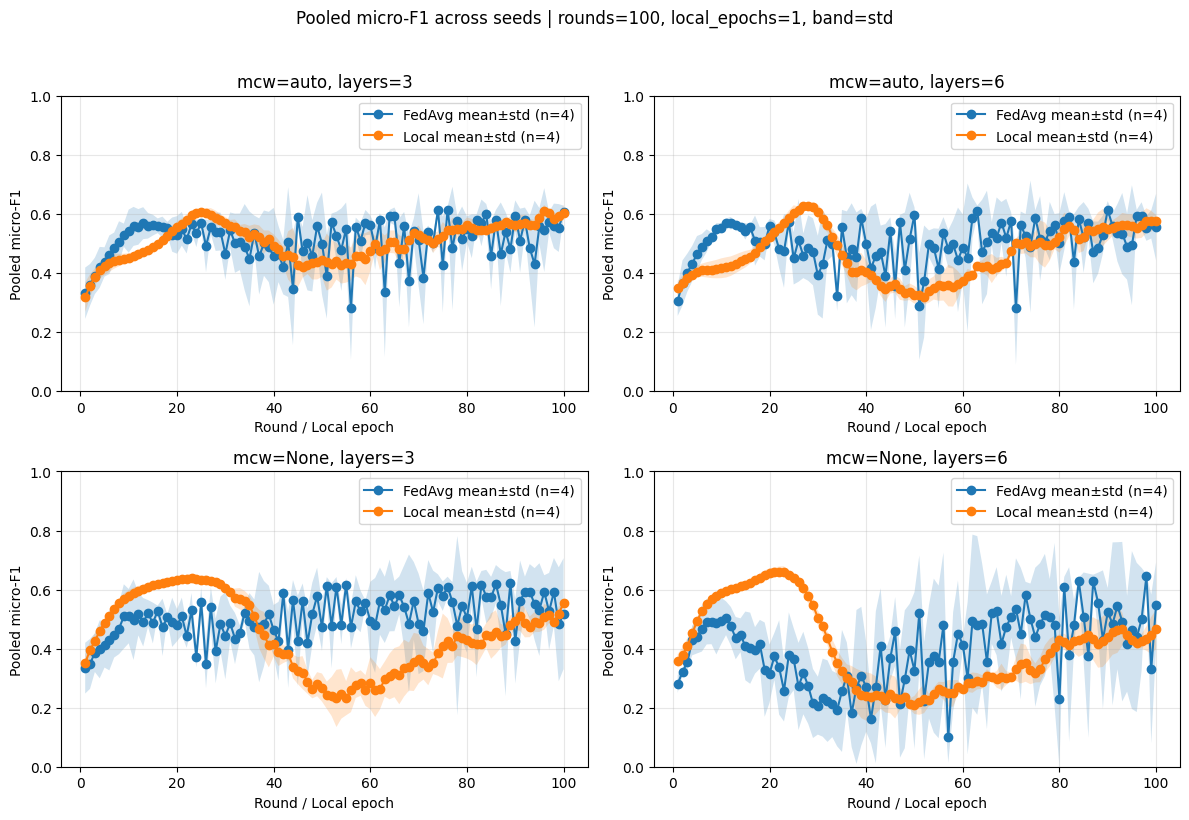

Saved combined plot to: plots/all_configs_rounds100_epochs1_std_micro.png


In [470]:
ncols = 2
nrows = int(np.ceil(n_cfg / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), squeeze=False)
axes = axes.flatten()

summary_rows = []

for ax, (mcw_val, layers_val) in zip(axes, configs):
    cfg_runs = selected_exp[
        (selected_exp["mcw"] == mcw_val) &
        (selected_exp["num_layers"] == layers_val)
    ].copy()
    
    fed_curves = []
    local_curves = []
    
    for _, exp in cfg_runs.iterrows():
        
        seed = exp["seed"]
        out_dir = exp["out_dir"]
        fed_curve, local_curve = load_seed_curve(out_dir)
        
        fed_curve["seed"] = seed
        local_curve["seed"] = seed
        
        fed_curves.append(fed_curve)
        local_curves.append(local_curve)
        
    fed_agg = aggregate_curves(fed_curves, "round")
    local_agg = aggregate_curves(local_curves, "local_epoch")

    if BAND_MODE == "std":
        fed_low = np.clip(fed_agg["mean"] - fed_agg["std"], 0, 1)
        fed_high = np.clip(fed_agg["mean"] + fed_agg["std"], 0, 1)

        local_low = np.clip(local_agg["mean"] - local_agg["std"], 0, 1)
        local_high = np.clip(local_agg["mean"] + local_agg["std"], 0, 1)

        fed_label = f"FedAvg mean±std (n={int(fed_agg['n_seeds'].max())})"
        local_label = f"Local mean±std (n={int(local_agg['n_seeds'].max())})"
    else:
        fed_low = fed_agg["min"]
        fed_high = fed_agg["max"]

        local_low = local_agg["min"]
        local_high = local_agg["max"]

        fed_label = f"FedAvg mean [min,max] (n={int(fed_agg['n_seeds'].max())})"
        local_label = f"Local mean [min,max] (n={int(local_agg['n_seeds'].max())})"

    plot_with_band(
        ax,
        fed_agg["round"].values,
        fed_agg["mean"].values,
        fed_low.values,
        fed_high.values,
        fed_label,
    )
    plot_with_band(
        ax,
        local_agg["local_epoch"].values,
        local_agg["mean"].values,
        local_low.values,
        local_high.values,
        local_label,
    )

    ax.set_xlabel("Round / Local epoch")
    ax.set_ylabel("Pooled micro-F1")
    ax.set_title(f"mcw={mcw_val}, layers={layers_val}")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    
for j in range(len(configs), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    f"Pooled micro-F1 across seeds | rounds={ROUNDS}, local_epochs={LOCAL_EPOCHS}, band={BAND_MODE}",
    y=1.02
)
fig.tight_layout()

PLOTS_ROOT.mkdir(parents=True, exist_ok=True)
big_plot_path = PLOTS_ROOT / f"all_configs_rounds{ROUNDS}_epochs{LOCAL_EPOCHS}_{BAND_MODE}_micro.png"
plt.savefig(big_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved combined plot to: {big_plot_path}")
    

In [431]:
def load_seed_macro_curve(out_dir):
    """
    Returns:
      fed_curve:   DataFrame [round, macro_f1_pooled]
      local_curve: DataFrame [local_epoch, macro_f1_pooled]
    """
    out_dir = str(out_dir).replace("andrea/", "")
    fedavg_df = pd.read_csv(Path(out_dir) / "fedavg.csv")
    local_df = pd.read_csv(Path(out_dir) / "local.csv")

    fedavg_val_task = fedavg_df[fedavg_df["phase"] == "global_val_client_task"].copy()
    local_val_task = local_df[local_df["phase"] == "val_task"].copy()

    # FedAvg: sum tp/fp/fn across clients for each (round, task)
    fed_round_task_agg = (
        fedavg_val_task
        .groupby(["round", "task"], as_index=False)[["tp", "fp", "fn"]]
        .sum()
        .sort_values(["round", "task"])
    )
    _, _, fed_round_task_agg["task_f1"] = f1_from_counts(
        fed_round_task_agg["tp"].values,
        fed_round_task_agg["fp"].values,
        fed_round_task_agg["fn"].values,
    )

    fed_curve = (
        fed_round_task_agg
        .groupby("round", as_index=False)["task_f1"]
        .mean()
        .rename(columns={"task_f1": "macro_f1_pooled"})
        .sort_values("round")
    )

    # Local: sum tp/fp/fn across clients for each (local_epoch, task)
    local_round_task_agg = (
        local_val_task
        .groupby(["local_epoch", "task"], as_index=False)[["tp", "fp", "fn"]]
        .sum()
        .sort_values(["local_epoch", "task"])
    )
    _, _, local_round_task_agg["task_f1"] = f1_from_counts(
        local_round_task_agg["tp"].values,
        local_round_task_agg["fp"].values,
        local_round_task_agg["fn"].values,
    )

    local_curve = (
        local_round_task_agg
        .groupby("local_epoch", as_index=False)["task_f1"]
        .mean()
        .rename(columns={"task_f1": "macro_f1_pooled"})
        .sort_values("local_epoch")
    )

    return fed_curve[["round", "macro_f1_pooled"]], local_curve[["local_epoch", "macro_f1_pooled"]]

def aggregate_metric_curves(curves, x_col, y_col):
    """
    curves: list of DataFrames with columns [x_col, y_col, seed]
    returns: DataFrame [x_col, mean, std, min, max, n_seeds]
    """
    if len(curves) == 0:
        return pd.DataFrame(columns=[x_col, "mean", "std", "min", "max", "n_seeds"])

    df = pd.concat(curves, ignore_index=True)

    agg = (
        df.groupby(x_col)[y_col]
        .agg(["mean", "std", "min", "max", "count"])
        .reset_index()
        .rename(columns={"count": "n_seeds"})
    )

    agg["std"] = agg["std"].fillna(0.0)
    return agg

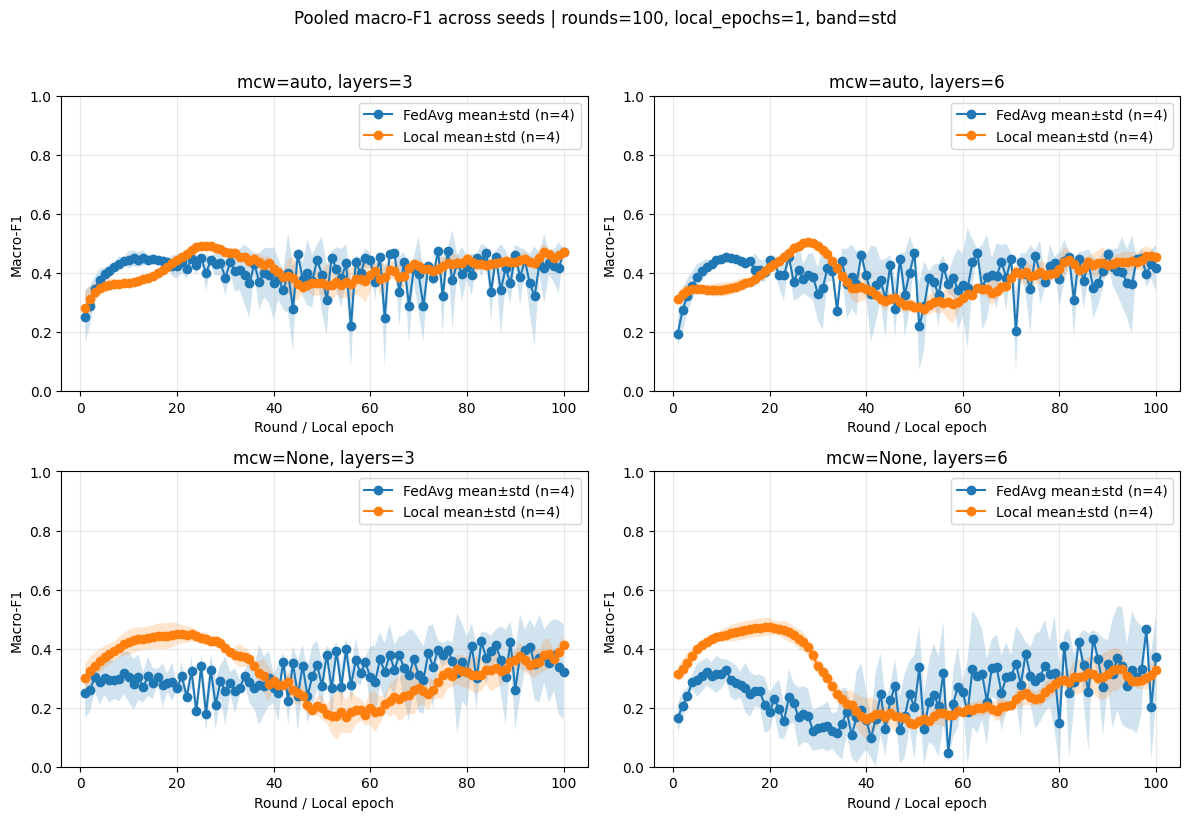

Saved combined plot to: plots/all_configs_rounds100_epochs1_std_macro.png


In [471]:
ncols = 2
nrows = int(np.ceil(n_cfg / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), squeeze=False)
axes = axes.flatten()

for ax, (mcw_val, layers_val) in zip(axes, configs):
    cfg_runs = selected_exp[
        (selected_exp["mcw"] == mcw_val) &
        (selected_exp["num_layers"] == layers_val)
    ].copy()

    fed_curves = []
    local_curves = []

    for _, exp in cfg_runs.iterrows():
        seed = exp["seed"]
        out_dir = exp["out_dir"]

        fed_curve, local_curve = load_seed_macro_curve(out_dir)

        fed_curve["seed"] = seed
        local_curve["seed"] = seed

        fed_curves.append(fed_curve)
        local_curves.append(local_curve)

    fed_agg = aggregate_metric_curves(fed_curves, "round", "macro_f1_pooled")
    local_agg = aggregate_metric_curves(local_curves, "local_epoch", "macro_f1_pooled")

    if BAND_MODE == "std":
        fed_low = np.clip(fed_agg["mean"] - fed_agg["std"], 0, 1)
        fed_high = np.clip(fed_agg["mean"] + fed_agg["std"], 0, 1)

        local_low = np.clip(local_agg["mean"] - local_agg["std"], 0, 1)
        local_high = np.clip(local_agg["mean"] + local_agg["std"], 0, 1)

        fed_label = f"FedAvg mean±std (n={int(fed_agg['n_seeds'].max())})"
        local_label = f"Local mean±std (n={int(local_agg['n_seeds'].max())})"
    else:
        fed_low = fed_agg["min"]
        fed_high = fed_agg["max"]

        local_low = local_agg["min"]
        local_high = local_agg["max"]

        fed_label = f"FedAvg mean [min,max] (n={int(fed_agg['n_seeds'].max())})"
        local_label = f"Local mean [min,max] (n={int(local_agg['n_seeds'].max())})"

    plot_with_band(
        ax,
        fed_agg["round"].values,
        fed_agg["mean"].values,
        fed_low.values,
        fed_high.values,
        fed_label,
    )

    plot_with_band(
        ax,
        local_agg["local_epoch"].values,
        local_agg["mean"].values,
        local_low.values,
        local_high.values,
        local_label,
    )

    ax.set_xlabel("Round / Local epoch")
    ax.set_ylabel("Macro-F1")
    ax.set_title(f"mcw={mcw_val}, layers={layers_val}")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

for j in range(len(configs), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    f"Pooled macro-F1 across seeds | rounds={ROUNDS}, local_epochs={LOCAL_EPOCHS}, band={BAND_MODE}",
    y=1.02
)
fig.tight_layout()

PLOTS_ROOT.mkdir(parents=True, exist_ok=True)
big_plot_path = PLOTS_ROOT / f"all_configs_rounds{ROUNDS}_epochs{LOCAL_EPOCHS}_{BAND_MODE}_macro.png"
plt.savefig(big_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved combined plot to: {big_plot_path}")

In [472]:
def load_seed_task_curves(out_dir):
    """
    Returns:
      fed_task_curve:   DataFrame [round, task, task_f1]
      local_task_curve: DataFrame [local_epoch, task, task_f1]
    """
    out_dir = str(out_dir).replace("andrea/", "")
    fedavg_df = pd.read_csv(Path(out_dir) / "fedavg.csv")
    local_df = pd.read_csv(Path(out_dir) / "local.csv")

    fedavg_val_task = fedavg_df[fedavg_df["phase"] == "global_val_client_task"].copy()
    local_val_task = local_df[local_df["phase"] == "val_task"].copy()

    fed_task_curve = (
        fedavg_val_task
        .groupby(["round", "task"], as_index=False)[["tp", "fp", "fn"]]
        .sum()
        .sort_values(["round", "task"])
    )
    _, _, fed_task_curve["task_f1"] = f1_from_counts(
        fed_task_curve["tp"].values,
        fed_task_curve["fp"].values,
        fed_task_curve["fn"].values,
    )

    local_task_curve = (
        local_val_task
        .groupby(["local_epoch", "task"], as_index=False)[["tp", "fp", "fn"]]
        .sum()
        .sort_values(["local_epoch", "task"])
    )
    _, _, local_task_curve["task_f1"] = f1_from_counts(
        local_task_curve["tp"].values,
        local_task_curve["fp"].values,
        local_task_curve["fn"].values,
    )

    return (
        fed_task_curve[["round", "task", "task_f1"]],
        local_task_curve[["local_epoch", "task", "task_f1"]],
    )
    
def aggregate_task_curves(curves, x_col):
    """
    curves: list of DataFrames with columns [x_col, task, task_f1, seed]
    returns: DataFrame [x_col, task, mean, std, min, max, n_seeds]
    """
    if len(curves) == 0:
        return pd.DataFrame(columns=[x_col, "task", "mean", "std", "min", "max", "n_seeds"])

    df = pd.concat(curves, ignore_index=True)

    agg = (
        df.groupby([x_col, "task"])["task_f1"]
        .agg(["mean", "std", "min", "max", "count"])
        .reset_index()
        .rename(columns={"count": "n_seeds"})
    )
    agg["std"] = agg["std"].fillna(0.0)
    return agg

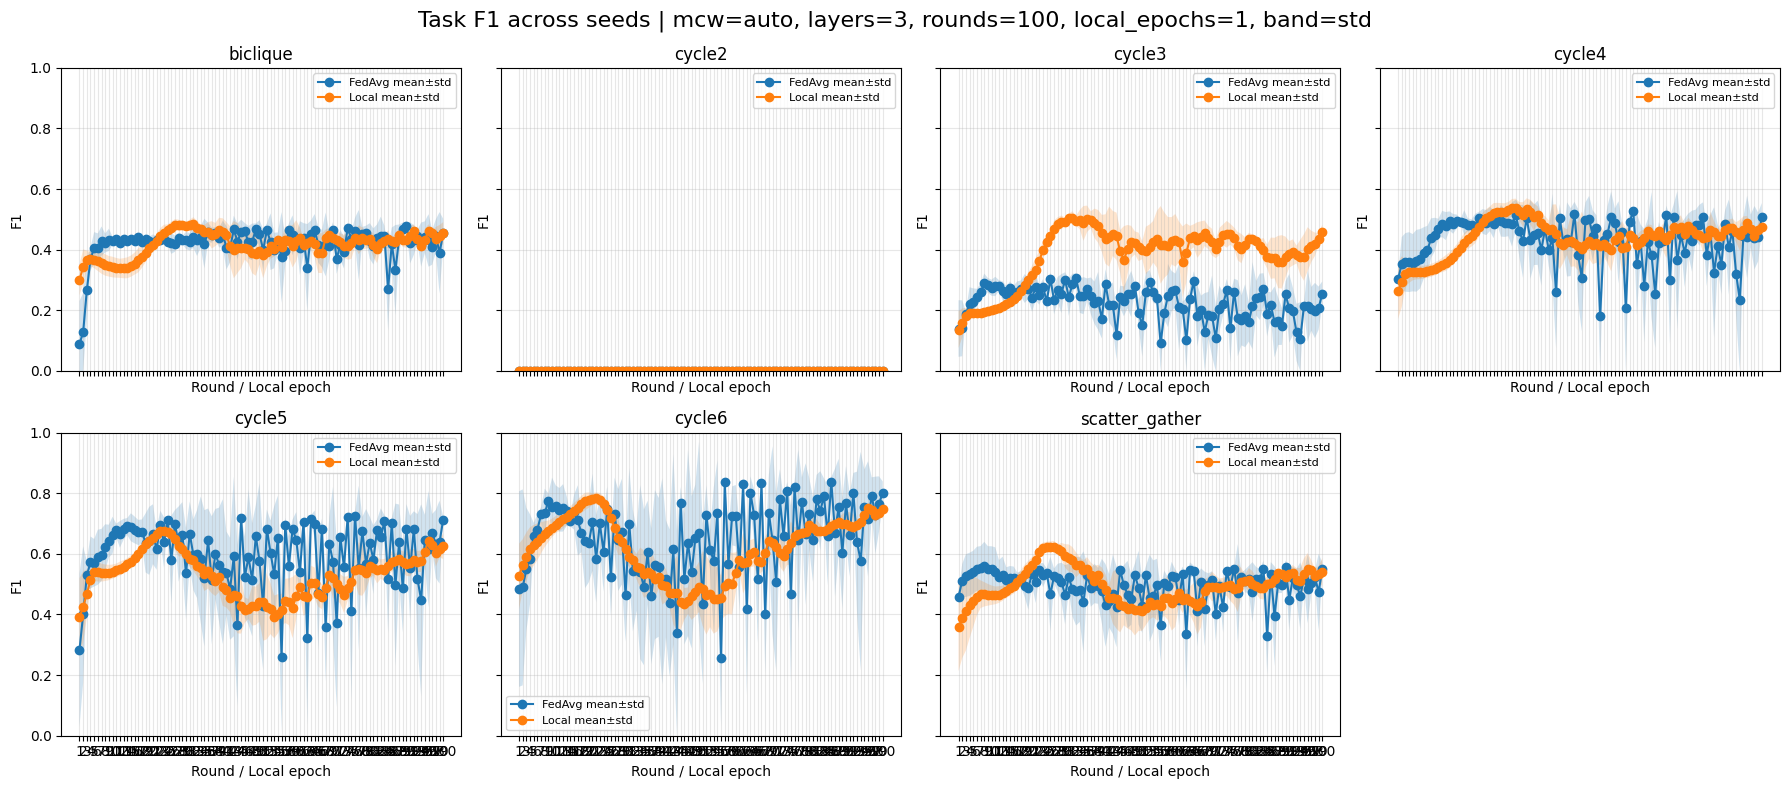

Saved: plots/task_f1_rounds100_epochs1_std_mcwauto_layers3.png


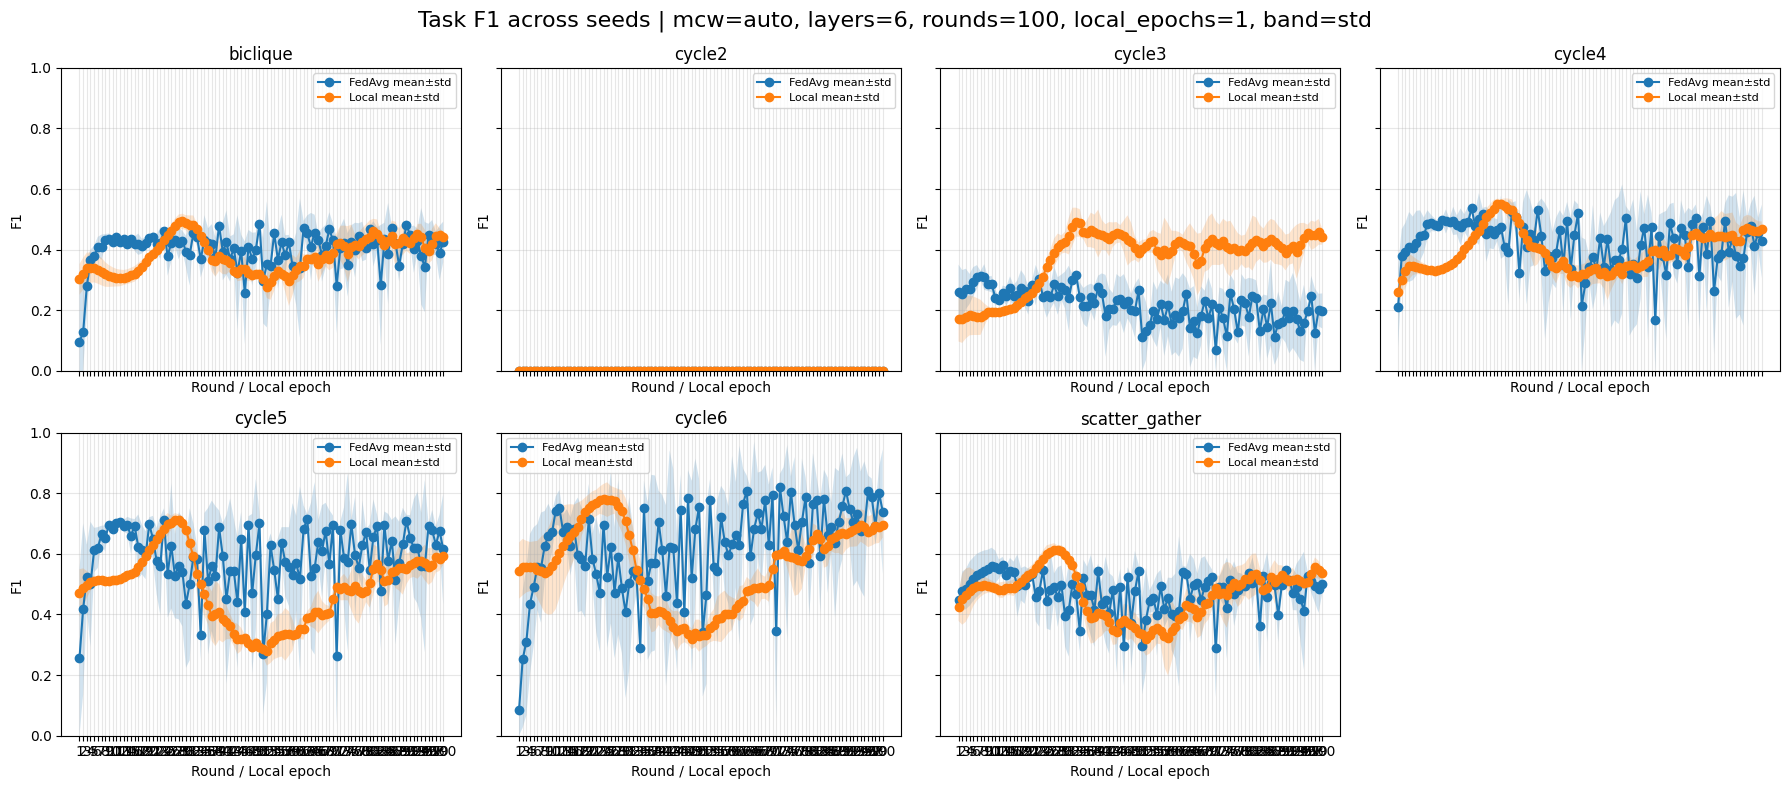

Saved: plots/task_f1_rounds100_epochs1_std_mcwauto_layers6.png


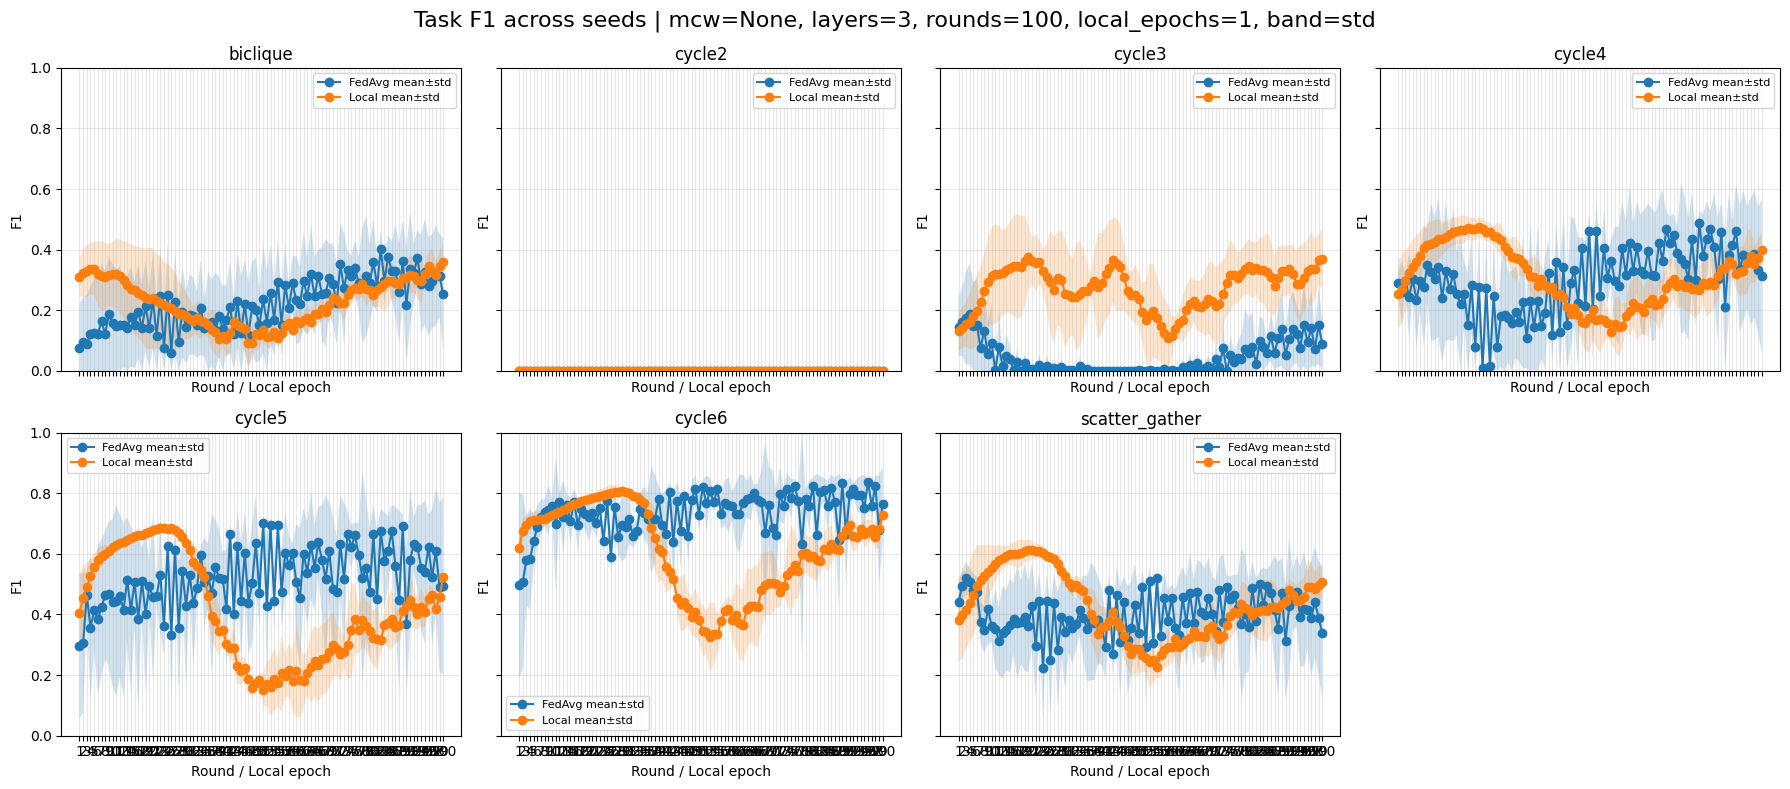

Saved: plots/task_f1_rounds100_epochs1_std_mcwNone_layers3.png


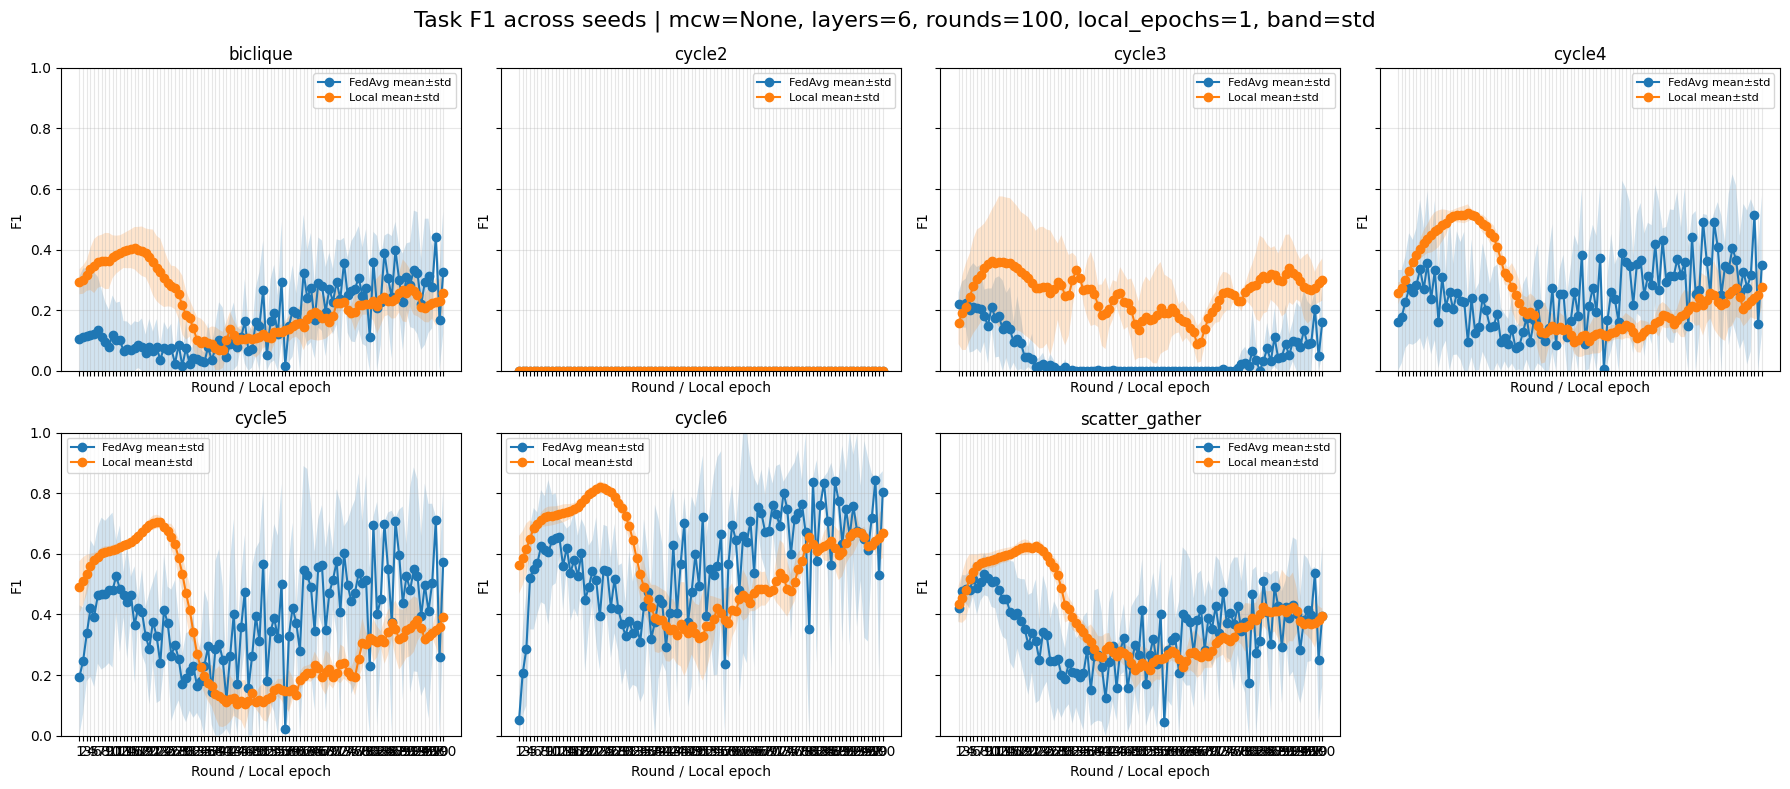

Saved: plots/task_f1_rounds100_epochs1_std_mcwNone_layers6.png


In [473]:
for mcw_val, layers_val in configs:
    cfg_runs = selected_exp[
        (selected_exp["mcw"] == mcw_val) &
        (selected_exp["num_layers"] == layers_val)
    ].copy()

    fed_task_curves = []
    local_task_curves = []

    for _, exp in cfg_runs.iterrows():
        seed = exp["seed"]
        out_dir = exp["out_dir"]

        fed_task_curve, local_task_curve = load_seed_task_curves(out_dir)

        fed_task_curve["seed"] = seed
        local_task_curve["seed"] = seed

        fed_task_curves.append(fed_task_curve)
        local_task_curves.append(local_task_curve)

    fed_task_agg = aggregate_task_curves(fed_task_curves, "round")
    local_task_agg = aggregate_task_curves(local_task_curves, "local_epoch")

    if fed_task_agg.empty or local_task_agg.empty:
        print(f"Skipping mcw={mcw_val}, layers={layers_val}: no task data found.")
        continue

    tasks = sorted(
        set(fed_task_agg["task"].dropna().unique()) |
        set(local_task_agg["task"].dropna().unique())
    )
    n_tasks = len(tasks)
    ncols = 4
    
    nrows = math.ceil(n_tasks / ncols)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.5 * ncols, 4 * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.flatten()

    all_rounds = sorted(fed_task_agg["round"].dropna().unique())

    for ax, task in zip(axes, tasks):
        fed_task_df = (
            fed_task_agg[fed_task_agg["task"] == task]
            .sort_values("round")
            .copy()
        )
        local_task_df = (
            local_task_agg[local_task_agg["task"] == task]
            .sort_values("local_epoch")
            .copy()
        )

        if BAND_MODE == "std":
            fed_low = np.clip(fed_task_df["mean"] - fed_task_df["std"], 0, 1)
            fed_high = np.clip(fed_task_df["mean"] + fed_task_df["std"], 0, 1)

            local_low = np.clip(local_task_df["mean"] - local_task_df["std"], 0, 1)
            local_high = np.clip(local_task_df["mean"] + local_task_df["std"], 0, 1)

            fed_label = f"FedAvg mean±std"
            local_label = f"Local mean±std"
        else:
            fed_low = fed_task_df["min"]
            fed_high = fed_task_df["max"]

            local_low = local_task_df["min"]
            local_high = local_task_df["max"]

            fed_label = f"FedAvg mean [min,max]"
            local_label = f"Local mean [min,max]"

        plot_with_band(
            ax,
            fed_task_df["round"].values,
            fed_task_df["mean"].values,
            fed_low.values,
            fed_high.values,
            fed_label,
        )

        plot_with_band(
            ax,
            local_task_df["local_epoch"].values,
            local_task_df["mean"].values,
            local_low.values,
            local_high.values,
            local_label,
        )

        ax.set_title(str(task))
        ax.set_xlabel("Round / Local epoch")
        ax.set_ylabel("F1")
        ax.set_xticks(all_rounds)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    for ax in axes[n_tasks:]:
        ax.set_visible(False)

    fig.suptitle(
        f"Task F1 across seeds | mcw={mcw_val}, layers={layers_val}, "
        f"rounds={ROUNDS}, local_epochs={LOCAL_EPOCHS}, band={BAND_MODE}",
        fontsize=16
    )
    fig.tight_layout()

    PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

    fig_path = PLOTS_ROOT / f"task_f1_rounds{ROUNDS}_epochs{LOCAL_EPOCHS}_{BAND_MODE}_mcw{mcw_val}_layers{layers_val}.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {fig_path}")